# Original plate-system matrix heat map

This notebook visualizes the original sparse plate-system matrix `K` loaded directly from `system_plate/plate_hole_data.pkl`. It intentionally does not use the solver notebook's symmetrized matrix `(K + K.T) / 2` or the Jacobi-scaled operator.

In [6]:
from pathlib import Path
import numpy as np
import os
import pickle
import tempfile

base_dir = Path("system_plate")
pickle_path = base_dir / "plate_hole_data.pkl"

# Keep matplotlib cache out of the repository while avoiding user-level write requirements.
matplotlib_cache_dir = Path(tempfile.gettempdir()) / "cg_hyperbox_matplotlib_cache"
os.environ.setdefault("MPLCONFIGDIR", str(matplotlib_cache_dir))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy import sparse

with pickle_path.open("rb") as file:
    K, F, U, B0_1, B0_2 = pickle.load(file)

K_original = K.tocsr() if sparse.issparse(K) else sparse.csr_matrix(np.asarray(K, dtype=float))
K_original.eliminate_zeros()

print(type(K_original.toarray()))

print(np.sum(np.abs(np.triu(K_original.toarray(), 1))))

 
n_rows, n_cols = K_original.shape
density = K_original.nnz / (n_rows * n_cols)
abs_data = np.abs(K_original.data)
nonzero_abs_data = abs_data[abs_data > 0]
asymmetry_norm = sparse.linalg.norm(K_original - K_original.T)

print("K_original shape:", K_original.shape)
print("K_original nnz:", K_original.nnz)
print(f"K_original density: {density:.6e}")
print(f"min |nonzero K_ij|: {nonzero_abs_data.min():.6e}")
print(f"max |nonzero K_ij|: {nonzero_abs_data.max():.6e}")
print(f"||K - K.T||_F: {asymmetry_norm:.6e}")

<class 'numpy.ndarray'>
0.0
K_original shape: (21570, 21570)
K_original nnz: 340779
K_original density: 7.324408e-04
min |nonzero K_ij|: 1.834421e-11
max |nonzero K_ij|: 4.672616e+03
||K - K.T||_F: 2.006992e+05


## Global sparse heat map

The full matrix is too large to densify, so this view bins the original sparse coordinates and colors each bin by the largest `log10(abs(K_ij))` value inside that bin. Empty bins are left blank.

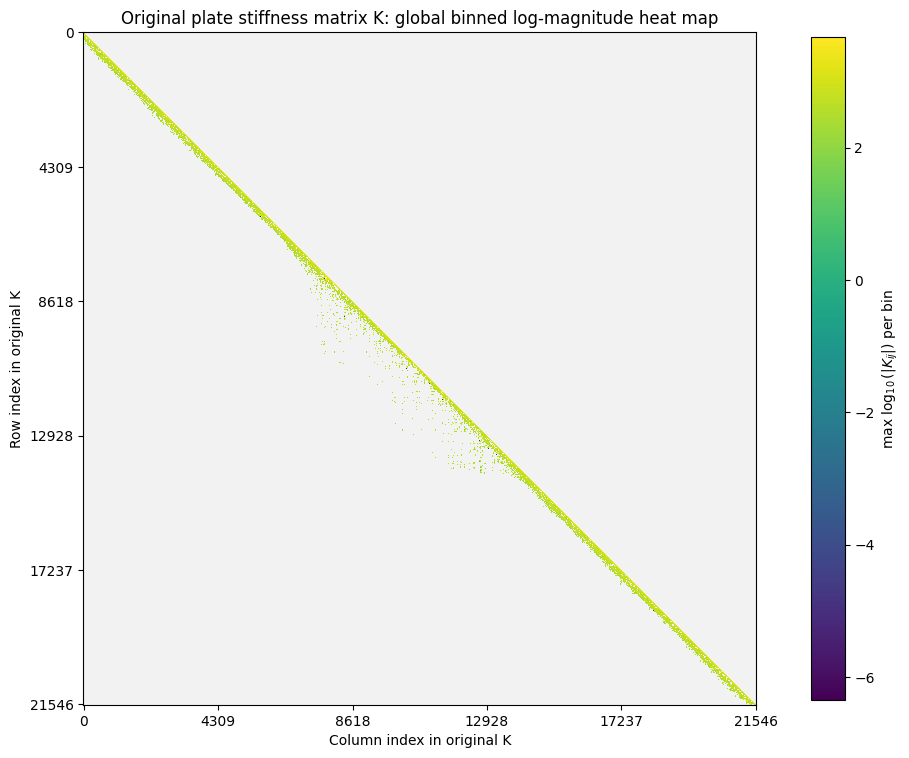

In [2]:
def sparse_log_magnitude_heatmap(matrix, bins=900):
    coo = matrix.tocoo()
    values = np.abs(coo.data)
    keep = values > 0
    row_bins = np.minimum((coo.row[keep] * bins) // matrix.shape[0], bins - 1)
    col_bins = np.minimum((coo.col[keep] * bins) // matrix.shape[1], bins - 1)

    grid = np.full((bins, bins), -np.inf, dtype=float)
    np.maximum.at(grid, (row_bins, col_bins), np.log10(values[keep]))
    grid[~np.isfinite(grid)] = np.nan
    return grid


GLOBAL_BINS = 900
global_heatmap = sparse_log_magnitude_heatmap(K_original, bins=GLOBAL_BINS)
cells_per_bin = K_original.shape[0] / GLOBAL_BINS

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("#f2f2f2")

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
image = ax.imshow(global_heatmap, origin="upper", interpolation="nearest", cmap=cmap, aspect="equal")
colorbar = fig.colorbar(image, ax=ax, shrink=0.85)
colorbar.set_label(r"max $\log_{10}(|K_{ij}|)$ per bin")

tick_positions = np.linspace(0, GLOBAL_BINS - 1, 6)
tick_labels = [f"{int(round(pos * cells_per_bin))}" for pos in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels)
ax.set_xlabel("Column index in original K")
ax.set_ylabel("Row index in original K")
ax.set_title("Original plate stiffness matrix K: global binned log-magnitude heat map")
plt.show()

## Leading-block signed heat map

This densifies only the leading block of the original matrix so the signed values are visible without changing the matrix.

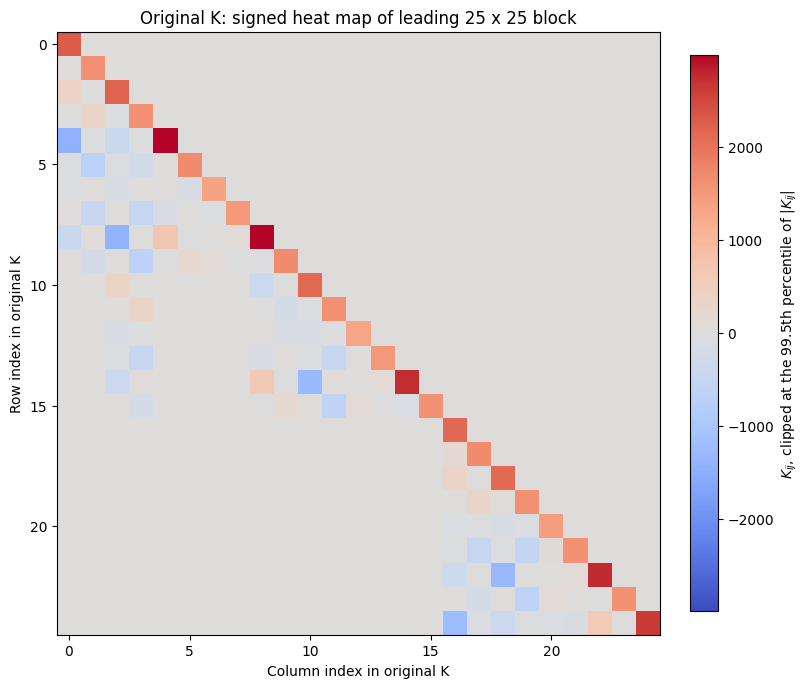

In [5]:
BLOCK_SIZE = 25
block_size = min(BLOCK_SIZE, K_original.shape[0], K_original.shape[1])
leading_block = K_original[:block_size, :block_size].toarray()

block_abs = np.abs(leading_block)
nonzero_block_abs = block_abs[block_abs > 0]
if nonzero_block_abs.size == 0:
    raise ValueError("The selected leading block contains no nonzero entries.")

limit = np.percentile(nonzero_block_abs, 99.5)
norm = TwoSlopeNorm(vmin=-limit, vcenter=0.0, vmax=limit)

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
image = ax.imshow(leading_block, origin="upper", interpolation="nearest", cmap="coolwarm", norm=norm, aspect="equal")
colorbar = fig.colorbar(image, ax=ax, shrink=0.85)
colorbar.set_label(r"$K_{ij}$, clipped at the 99.5th percentile of $|K_{ij}|$")
ax.set_xlabel("Column index in original K")
ax.set_ylabel("Row index in original K")
ax.set_title(f"Original K: signed heat map of leading {block_size} x {block_size} block")
plt.show()